# Training a ML Model to Predict Drowsiness

In this notebook, I cleaned up and documented the original methodology used to train our models.

In another notebook, called `train_RF_enhanced`, I present a faster and more optimized approach that makes better use of the available data. This approach is based on understanding how the Random Forest (RF) algorithm works and how the data can be prepared to make RF a more suitable algorithm for this task.

I also address the data leakage issue present in this notebook and fine-tune the model using GridSearchCV and RandomizedSearchCV with cross-validation, following the approach used in the original project. The original project files were too messy to be included in the cleaned-up version, and the methodology used there is very similar to the one presented in this notebook.


## Get the data

In [2]:
import pandas as pd

# Load data
df_signe = pd.read_csv('csv/signes.csv')
df_signe.head()

,video_name,EAR_left_0,EAR_right_0,EAR_mean_0,MAR_0,EBR_0,PERCLOS_0,HOP_gd_0,HOP_hb_0,EAR_left_1,...,HOP_hb_873,EAR_left_874,EAR_right_874,EAR_mean_874,MAR_874,EBR_874,PERCLOS_874,HOP_gd_874,HOP_hb_874,class
0,kss#1-3#F#rldd#17-0.mp4_1.mp4,0.368546,0.371066,0.369806,0.003794,0,0.0,89.996526,4.465502,0.378372,...,3.538908,0.366793,0.366085,0.366439,0.003091,0,8.000000,89.994856,3.620867,0
1,kss#1-3#F#rldd#21-0.mp4_1.mp4,0.315517,0.281914,0.298715,0.006160,0,0.0,90.012625,2.051549,0.314886,...,5.143141,0.345992,0.292497,0.319244,0.007726,0,2.400000,90.015657,5.207324,0
2,kss#1-3#F#rldd#57-0.mp4_5.mp4,0.312824,0.290006,0.301415,0.003691,0,0.0,90.021010,5.515728,0.321846,...,4.564574,0.286394,0.249781,0.268087,0.006888,1,4.800000,90.026613,4.552479,0
3,kss#1-3#F#rldd#59-0.mp4_4.mp4,0.331562,0.346838,0.339200,0.003254,0,0.0,89.986877,1.336402,0.341735,...,0.507546,0.348462,0.353522,0.350992,0.003047,0,13.714286,89.994275,0.511410,0
4,kss#8-9#F#rldd#12-10.mp4_3.mp4,0.318018,0.338801,0.328409,0.009697,0,0.0,89.974311,4.051703,0.320297,...,2.222282,0.122808,0.119565,0.121187,0.009761,1,21.714286,89.975156,2.369169,2


We know from the EDA that the dataset is clean and contains no missing values.


## Prepare data

This splitting strategy introduces data leakage, as multiple videos from the same person can end up in both the training and test sets. This issue is addressed in `train_RF_enhanced.ipynb`.

In [14]:
from sklearn.model_selection import train_test_split

# Get the feature columns
colonnes_X = df_signe.columns.drop('class')

X = df_signe[colonnes_X]
y = df_signe['class']

# Stratify the split to preserve the class distribution, as the classes are imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Remove the video name from the training and test sets
X_train = X_train.drop(columns=['video_name'])
X_test = X_test.drop(columns=['video_name'])

## Training Models

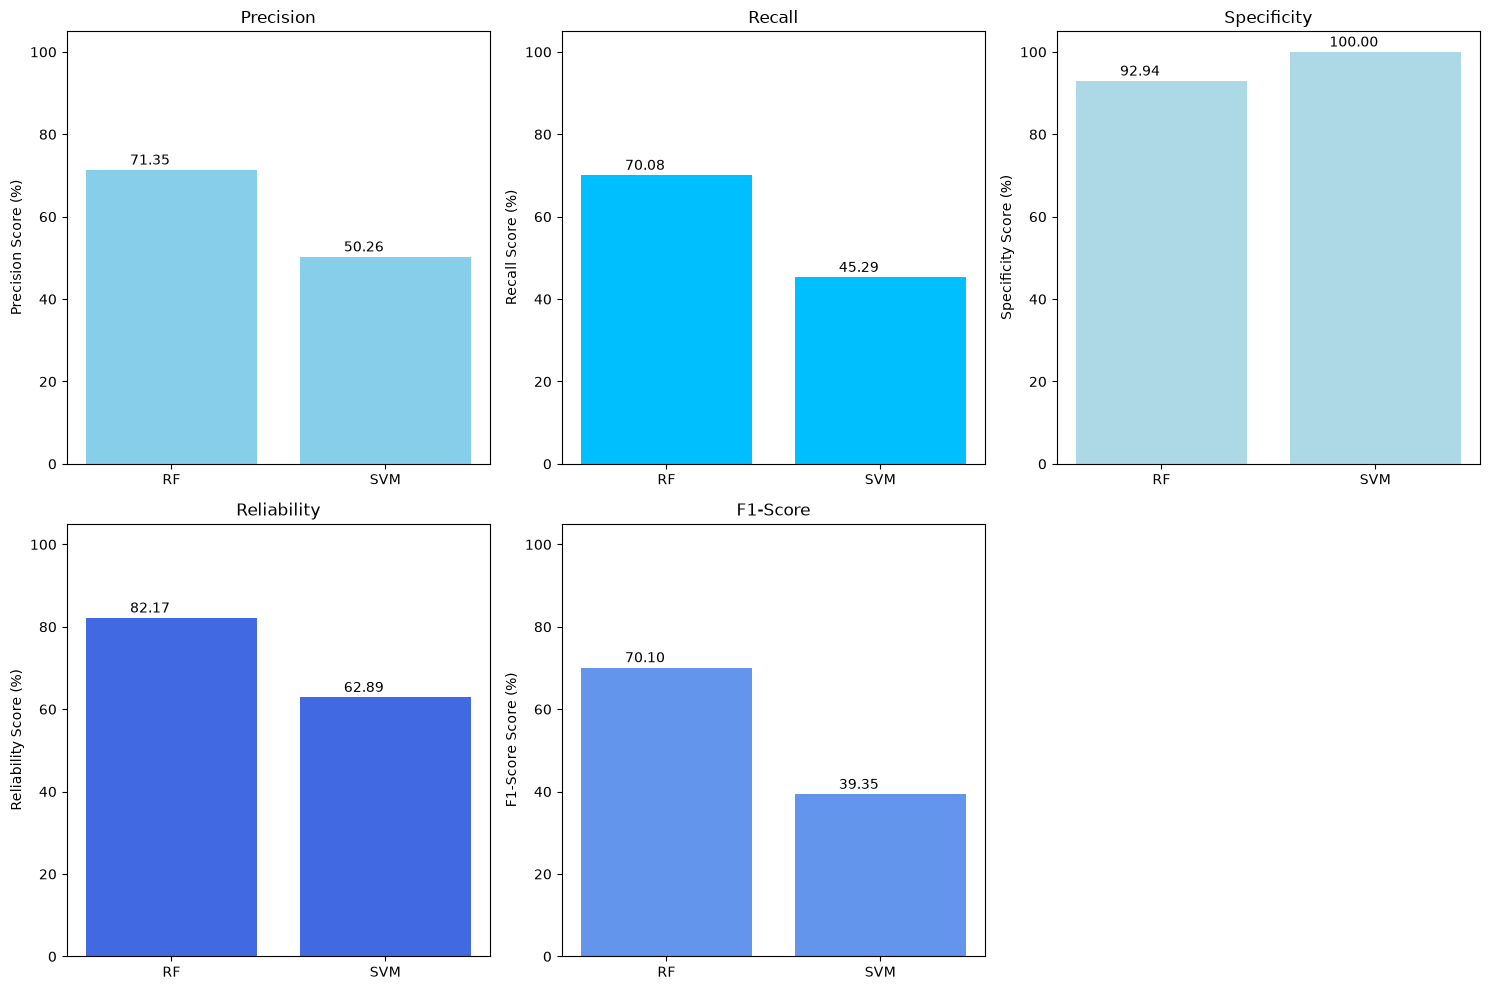

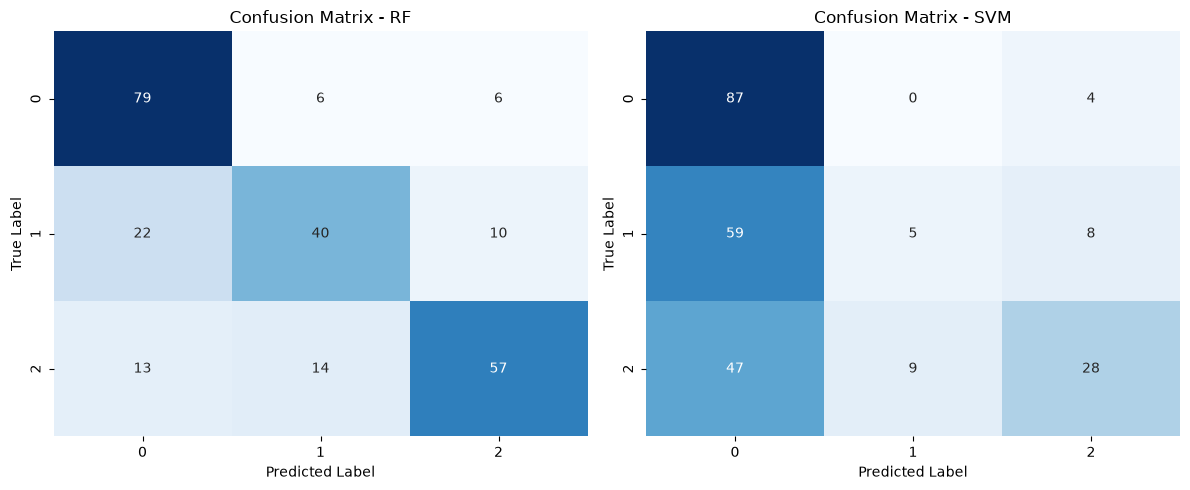

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.svm import SVC

# Define classifiers to test
classifiers = {
    'RF': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True),
}

# Dictionaries to store performance metrics and confusion matrices
results_precision = {}
results_recall = {}
results_specificity = {}
results_reliability = {}
results_f1 = {}
results_cm = {}

for name, clf in classifiers.items():
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  results_cm[name] = cm
  tn, fp, fn = cm[0, 0], cm[0, 1], cm[1, 0]
  tp = cm[1, 1] if cm.shape[0] == 2 else cm[1, 1:].sum()

  # Calculate metrics as percentages
  results_precision[name] = precision_score(y_test, y_pred, average='macro') * 100
  results_recall[name] = recall_score(y_test, y_pred, average='macro') * 100
  results_specificity[name] = (tn / (tn + fp)) * 100
  results_reliability[name] = ((tp + tn) / (tp + tn + fp + fn)) * 100
  results_f1[name] = f1_score(y_test, y_pred, average='macro') * 100

# Plotting metrics for each classifier (using a 2x3 grid)
metrics = {
    'Precision': (results_precision, 'skyblue'),
    'Recall': (results_recall, 'deepskyblue'),
    'Specificity': (results_specificity, 'lightblue'),
    'Reliability': (results_reliability, 'royalblue'),
    'F1-Score': (results_f1, 'cornflowerblue'),
}

plt.figure(figsize=(15, 10))

for i, (title, (data, color)) in enumerate(metrics.items(), 1):
  plt.subplot(2, 3, i)
  bars = plt.bar(data.keys(), data.values(), color=color)
  plt.title(title)
  plt.ylabel(f'{title} Score (%)')
  plt.ylim(0, 105)

  for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2 - 0.1,
        bar.get_height() + 0.5,
        f'{bar.get_height():.2f}',
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

# Plotting confusion matrices for each classifier
plt.figure(figsize=(12, 5))
for i, (name, cm) in enumerate(results_cm.items(), 1):
  plt.subplot(1, len(classifiers), i)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
  plt.title(f'Confusion Matrix - {name}')
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')

plt.tight_layout()
plt.show()

With the background knowledge I have now, it is clear why both SVM and Random Forest were not ideal choices for this representation. Both models had to make predictions from 7,000 raw temporal features, resulting in a high-dimensional feature space where the temporal patterns were not explicitly represented. Instead of capturing meaningful behaviors over time, the models had to learn decision rules directly from individual time steps.

The relatively acceptable F1-score obtained with Random Forest (around 0.70) should also be interpreted with caution. The original train/test split introduced data leakage, as different sequences from the same person or original video could be present in both sets. This means that the reported performance may be partially inflated by the model learning person- or video-specific characteristics rather than generalizable patterns of drowsiness.

This issue is addressed in `train_RF_enhanced.ipynb`.


## Fine-tuned model

The fine-tuned model found by the team using GridSearch and RandomSearch

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

# Define the hyperparameters for each classifier
parametres = {
    'RFt': {
        'n_estimators': 600,
        'max_depth': None,
        'min_samples_split': 5,
        'min_samples_leaf': 1,
        'random_state': 42,
    }
}

# Initialize the classifiers with the specified hyperparameters
classifieurs = {'RFt': RandomForestClassifier(**parametres['RFt'])}

# Dictionaries used to store the evaluation metrics
resultats_precision = {}
resultats_sensibilite = {}
resultats_specificite = {}
resultats_fiabilite = {}
resultats_f1 = {}

for nom_clf, clf in classifieurs.items():
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)

  # Compute the confusion matrix
  cm = confusion_matrix(y_test, y_pred)

  # Extract the confusion matrix components
  tn, fp, fn = cm[0, 0], cm[0, 1], cm[1, 0]
  tp = cm[1, 1] if cm.shape[0] == 2 else cm[1, 1:].sum()

  # Compute the evaluation metrics
  precision = precision_score(y_test, y_pred, average='macro')
  sensibilite = recall_score(y_test, y_pred, average='macro')
  specificite = tn / (tn + fp)
  fiabilite = (tp + tn) / (tp + tn + fp + fn)
  f1 = f1_score(y_test, y_pred, average='macro')

  # Store the results
  resultats_precision[nom_clf] = precision
  resultats_sensibilite[nom_clf] = sensibilite
  resultats_specificite[nom_clf] = specificite
  resultats_fiabilite[nom_clf] = fiabilite
  resultats_f1[nom_clf] = f1

  # Display the confusion matrix with annotations
  plt.figure(figsize=(6, 4))
  sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)

  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title(f'Confusion Matrix - {nom_clf}')
  plt.show()

  print(f'Precision for {nom_clf}: {precision}')
  print(f'Sensitivity for {nom_clf}: {sensibilite}')
  print(f'Specificity for {nom_clf}: {specificite}')
  print(f'Reliability for {nom_clf}: {fiabilite}')
  print(f'F1-Score for {nom_clf}: {f1}')

print('Done!')